# Web RAG Evaluation Comparison Notebook

This notebook compares the three Web RAG reranking methods implemented in the project:

- `lexical`
- `medcpt`
- `hybrid`

The notebook reads the already saved evaluation CSV files from `outputs/evaluation/` and does **not** rerun retrieval or evaluation. This keeps the visualization reproducible and presentation-friendly.

## 1. Load evaluation results

Expected input files:

```text
outputs/evaluation/lexical/evaluation_results.csv
outputs/evaluation/semantic/evaluation_results.csv
```

The CSV files may contain repeated runs. The notebook keeps the **latest row** for each combination of `layer`, `metric`, `ranker`, and `k`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANKER_ORDER = ["lexical", "medcpt", "hybrid"]
LEXICAL_METRIC_ORDER = ["ROUGE1_Nugget", "ROUGEL_Nugget", "ROUGE_Nugget", "BM25_Nugget"]
SEMANTIC_METRIC_ORDER = ["SemanticNuggetMatch", "SemanticAnswerMatch"]


def find_project_root() -> Path:
    """Find the project root from either the root folder or the notebooks folder."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        lexical_path = candidate / "outputs" / "evaluation" / "lexical" / "evaluation_results.csv"
        semantic_path = candidate / "outputs" / "evaluation" / "semantic" / "evaluation_results.csv"
        if lexical_path.exists() and semantic_path.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find outputs/evaluation/lexical/evaluation_results.csv and "
        "outputs/evaluation/semantic/evaluation_results.csv. Run this notebook from the project root "
        "or from the notebooks folder."
    )

PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

lexical_path = OUTPUTS_DIR / "evaluation" / "lexical" / "evaluation_results.csv"
semantic_path = OUTPUTS_DIR / "evaluation" / "semantic" / "evaluation_results.csv"

lexical_df = pd.read_csv(lexical_path)
semantic_df = pd.read_csv(semantic_path)
all_results = pd.concat([lexical_df, semantic_df], ignore_index=True)

all_results["timestamp"] = pd.to_datetime(all_results["timestamp"], errors="coerce")
latest_results = (
    all_results
    .sort_values("timestamp")
    .drop_duplicates(subset=["layer", "metric", "ranker", "k"], keep="last")
    .reset_index(drop=True)
)

latest_results["ranker"] = pd.Categorical(latest_results["ranker"], categories=RANKER_ORDER, ordered=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded {len(lexical_df)} lexical rows and {len(semantic_df)} semantic rows.")
print(f"Using {len(latest_results)} latest metric rows for comparison.")

Project root: C:\Users\taymm\Desktop\ProvideQ\provideq-web-rag
Loaded 12 lexical rows and 6 semantic rows.
Using 18 latest metric rows for comparison.


## 2. Latest evaluation table

This table is the main combined result table. Each row corresponds to one evaluation metric, one reranker, and one `k` value.

In [2]:
summary_columns = [
    "layer",
    "metric",
    "ranker",
    "k",
    "score",
    "questions_evaluated",
    "total_gold_nuggets",
]

display(
    latest_results[summary_columns]
    .sort_values(["layer", "metric", "ranker"])
    .assign(score=lambda df: df["score"].round(4))
)

,layer,metric,ranker,k,score,questions_evaluated,total_gold_nuggets
3,lexical,BM25_Nugget,lexical,5,0.1832,20,81
7,lexical,BM25_Nugget,medcpt,5,0.1704,20,81
15,lexical,BM25_Nugget,hybrid,5,0.1836,20,81
0,lexical,ROUGE1_Nugget,lexical,5,0.4292,20,81
4,lexical,ROUGE1_Nugget,medcpt,5,0.4219,20,81
12,lexical,ROUGE1_Nugget,hybrid,5,0.4384,20,81
1,lexical,ROUGEL_Nugget,lexical,5,0.3648,20,81
5,lexical,ROUGEL_Nugget,medcpt,5,0.3502,20,81
14,lexical,ROUGEL_Nugget,hybrid,5,0.3673,20,81
2,lexical,ROUGE_Nugget,lexical,5,0.3970,20,81


## 3. Pivot tables for thesis reporting

The following tables are useful for slides and thesis text because they show one row per metric and one column per reranker.

In [3]:
def make_metric_pivot(df: pd.DataFrame, layer: str, metric_order: list[str]) -> pd.DataFrame:
    subset = df[df["layer"] == layer].copy()
    pivot = subset.pivot_table(index="metric", columns="ranker", values="score", aggfunc="last")
    pivot = pivot.reindex(metric_order)
    pivot = pivot.reindex(columns=RANKER_ORDER)
    return pivot.round(4)

lexical_pivot = make_metric_pivot(latest_results, "lexical", LEXICAL_METRIC_ORDER)
semantic_pivot = make_metric_pivot(latest_results, "semantic", SEMANTIC_METRIC_ORDER)

print("Lexical evaluation metrics")
display(lexical_pivot)

print("Semantic evaluation metrics")
display(semantic_pivot)

Lexical evaluation metrics


ranker,lexical,medcpt,hybrid
metric,,,
ROUGE1_Nugget,0.4292,0.4219,0.4384
ROUGEL_Nugget,0.3648,0.3502,0.3673
ROUGE_Nugget,0.3970,0.3861,0.4029
BM25_Nugget,0.1832,0.1704,0.1836


Semantic evaluation metrics


ranker,lexical,medcpt,hybrid
metric,,,
SemanticNuggetMatch,0.4192,0.4258,0.4300
SemanticAnswerMatch,0.5493,0.5871,0.5946


## 4. Best reranker per metric

This table identifies which reranker achieved the highest score for each metric. It is useful for a short result interpretation.

In [4]:
best_rows = []
for (layer, metric), group in latest_results.groupby(["layer", "metric"], observed=False):
    group = group.dropna(subset=["score"])
    if group.empty:
        continue
    best = group.loc[group["score"].idxmax()]
    best_rows.append({
        "layer": layer,
        "metric": metric,
        "best_ranker": best["ranker"],
        "k": int(best["k"]),
        "score": round(float(best["score"]), 4),
    })

best_df = pd.DataFrame(best_rows).sort_values(["layer", "metric"]).reset_index(drop=True)
display(best_df)

,layer,metric,best_ranker,k,score
0,lexical,BM25_Nugget,hybrid,5,0.1835
1,lexical,ROUGE1_Nugget,hybrid,5,0.4384
2,lexical,ROUGEL_Nugget,hybrid,5,0.3673
3,lexical,ROUGE_Nugget,hybrid,5,0.4029
4,semantic,SemanticAnswerMatch,hybrid,5,0.5946
5,semantic,SemanticNuggetMatch,hybrid,5,0.4300


## 5. Retrieval diagnostics

The evaluation scores should be interpreted together with retrieval coverage. This table checks how many benchmark questions returned evidence for each reranker.

In [5]:
def load_retrieval_results(outputs_dir: Path) -> pd.DataFrame:
    frames = []
    for ranker in RANKER_ORDER:
        path = outputs_dir / f"ranker_{ranker}" / "retrieval_results.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df["ranker"] = ranker
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

retrieval_df = load_retrieval_results(OUTPUTS_DIR)

if retrieval_df.empty:
    print("No retrieval result CSV files found.")
else:
    retrieval_diagnostics = (
        retrieval_df
        .groupby("ranker", observed=False)
        .agg(
            questions=("question_id", "count"),
            questions_with_evidence=("returned_records_count", lambda s: int((s.fillna(0) > 0).sum())),
            avg_returned_records=("returned_records_count", "mean"),
            avg_retrieved_papers=("retrieved_papers_count", "mean"),
            avg_extracted_snippets=("extracted_snippets_count", "mean"),
        )
        .reindex(RANKER_ORDER)
        .reset_index()
    )
    retrieval_diagnostics["coverage"] = (
        retrieval_diagnostics["questions_with_evidence"] / retrieval_diagnostics["questions"]
    ).round(3)
    display(retrieval_diagnostics.round(3))

,ranker,questions,questions_with_evidence,avg_returned_records,avg_retrieved_papers,avg_extracted_snippets,coverage
0,lexical,20,20,5.0,8.0,82.2,1.0
1,medcpt,20,20,5.0,8.0,82.2,1.0
2,hybrid,20,20,5.0,8.0,82.2,1.0


## 6. Plot helper

Each plot below compares the three rerankers for exactly one metric. Scores are shown on a 0–1 scale.

In [6]:
def plot_metric(df: pd.DataFrame, layer: str, metric: str, title: str) -> None:
    subset = df[(df["layer"] == layer) & (df["metric"] == metric)].copy()
    subset = subset.sort_values("ranker")
    subset = subset.set_index("ranker").reindex(RANKER_ORDER).reset_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(subset["ranker"].astype(str), subset["score"])
    ax.set_title(title)
    ax.set_xlabel("Reranker")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.bar_label(bars, labels=[f"{v:.3f}" if pd.notna(v) else "" for v in subset["score"]], padding=3)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## ROUGE-1 Nugget@5: lexical overlap with gold nuggets

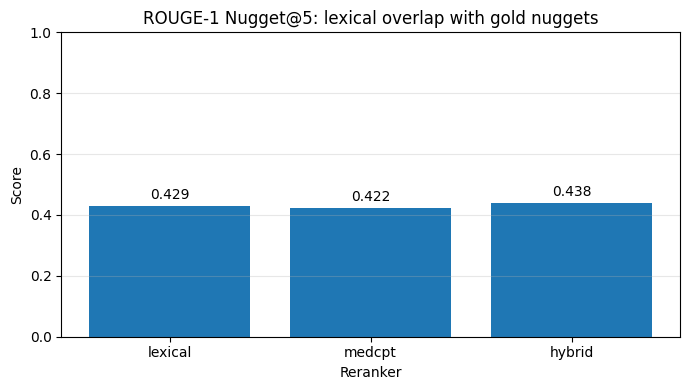

In [7]:
plot_metric(latest_results, layer='lexical', metric='ROUGE1_Nugget', title='ROUGE-1 Nugget@5: lexical overlap with gold nuggets')

## ROUGE-L Nugget@5: longest-sequence overlap with gold nuggets

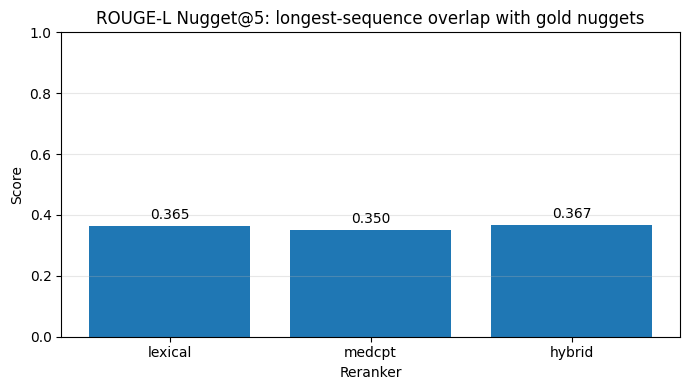

In [8]:
plot_metric(latest_results, layer='lexical', metric='ROUGEL_Nugget', title='ROUGE-L Nugget@5: longest-sequence overlap with gold nuggets')

## Average ROUGE Nugget@5: combined lexical coverage

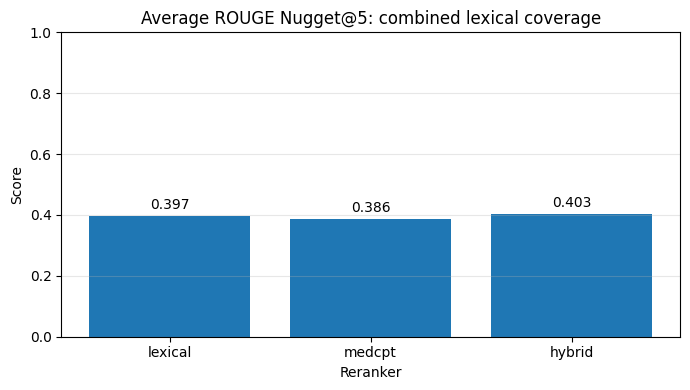

In [9]:
plot_metric(latest_results, layer='lexical', metric='ROUGE_Nugget', title='Average ROUGE Nugget@5: combined lexical coverage')

## BM25 Nugget@5: lexical IR-style nugget coverage

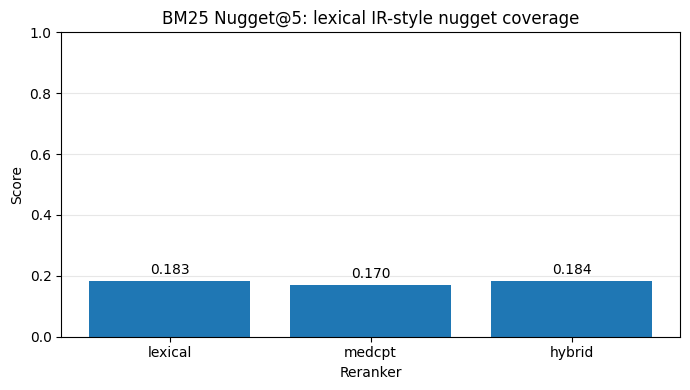

In [10]:
plot_metric(latest_results, layer='lexical', metric='BM25_Nugget', title='BM25 Nugget@5: lexical IR-style nugget coverage')

## SemanticNuggetMatch@5: embedding match to gold nuggets

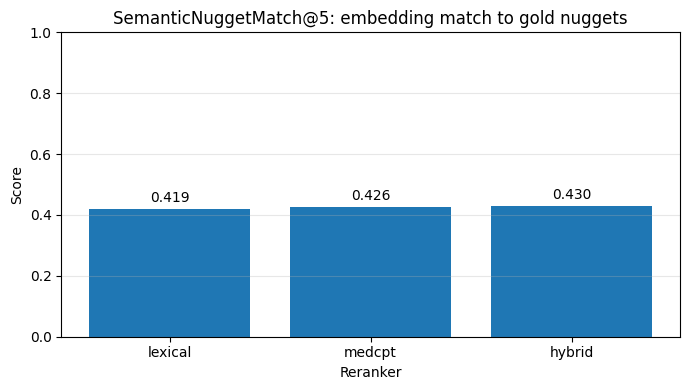

In [11]:
plot_metric(latest_results, layer='semantic', metric='SemanticNuggetMatch', title='SemanticNuggetMatch@5: embedding match to gold nuggets')

## SemanticAnswerMatch@5: embedding match to gold answer

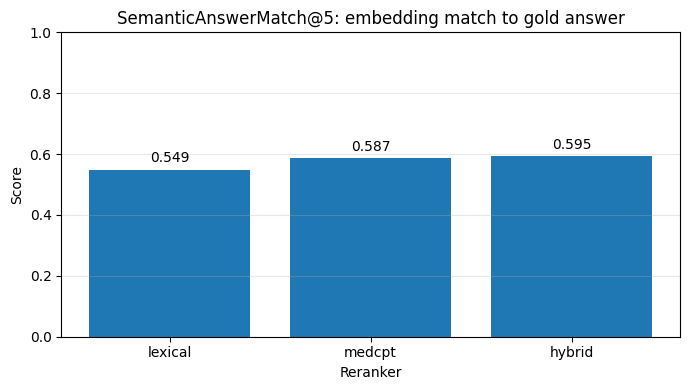

In [12]:
plot_metric(latest_results, layer='semantic', metric='SemanticAnswerMatch', title='SemanticAnswerMatch@5: embedding match to gold answer')

## 7. Short interpretation template

Use this cell to write the interpretation after checking the final plots. A good thesis-level interpretation should mention:

1. which reranker performs best per metric,
2. whether lexical and semantic metrics agree,
3. whether improvements are large or small,
4. and whether retrieval coverage/noise may explain the result.

For the current outputs, the hybrid reranker is expected to be competitive because it combines lexical term matching with MedCPT-based biomedical semantic scoring.

In [13]:
overall_summary = (
    latest_results
    .groupby(["layer", "ranker"], observed=False)["score"]
    .mean()
    .reset_index()
    .sort_values(["layer", "score"], ascending=[True, False])
)

display(overall_summary.assign(score=lambda df: df["score"].round(4)))

,layer,ranker,score
2,lexical,hybrid,0.3480
0,lexical,lexical,0.3436
1,lexical,medcpt,0.3321
5,semantic,hybrid,0.5123
4,semantic,medcpt,0.5064
3,semantic,lexical,0.4843
